# Gene Expression copy number correction

June 11, 2024

## Goal:
Apply copy number correction to gene expression data

**Procedure:**
1. Load replication timing
2. Load gene expression data for all genes (may take a while, start with a smaller set)
4. Copy number correction
5. Store corrected data for deconvolution


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from src.CopyNumberCorrection import CopyNumberCorrector

corrector = CopyNumberCorrector()
corrector.compute_replication_timing()

In [6]:
corrector.load_gene_expression_data(1)

In [7]:
corrector.correct_for_copy_number()

0/4835 - 00:00:00.002
1000/4835 - 00:00:00.675
2000/4835 - 00:00:01.399
3000/4835 - 00:00:02.113
4000/4835 - 00:00:02.833


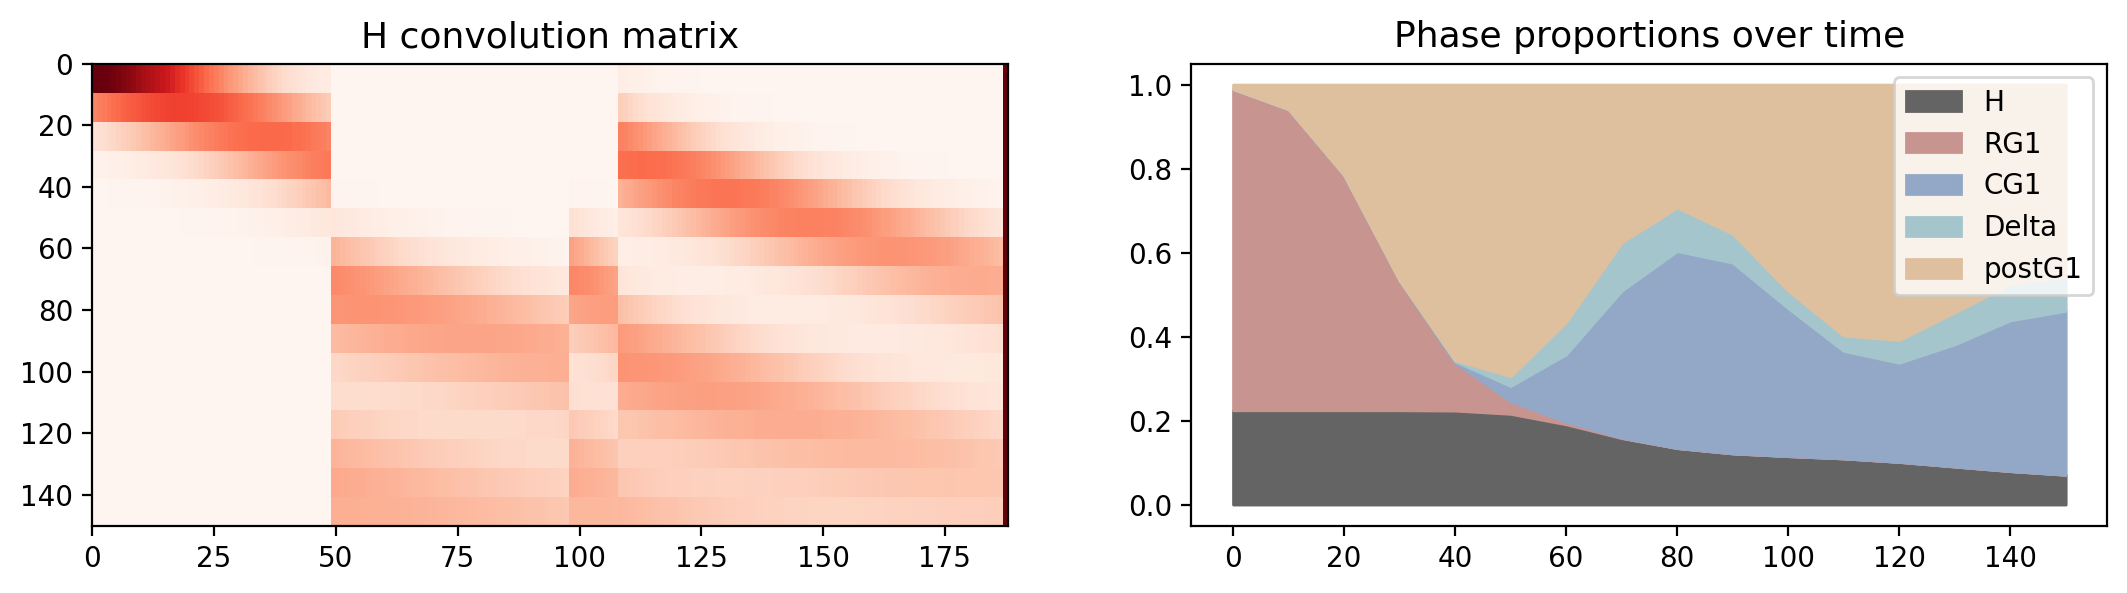

In [8]:
from src.delta_config import plot_H

plot_H(corrector.config, corrector.H)

In [9]:
corrector.compute_ptrs()

(0.99, 1.25)

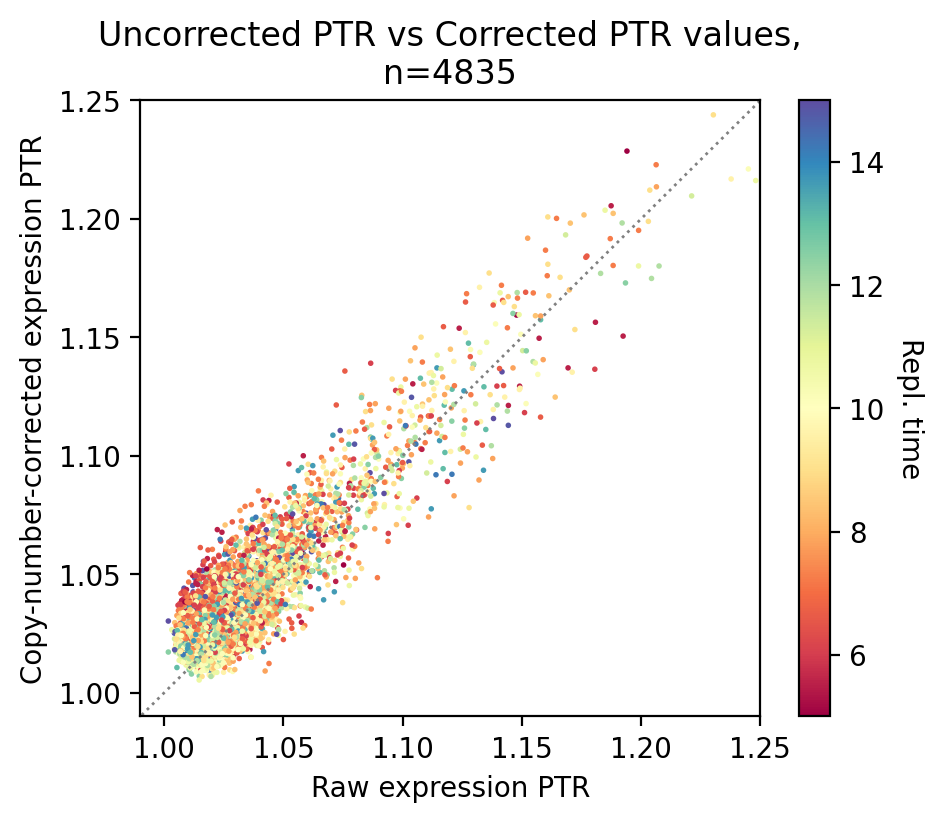

In [10]:
corrector.plot_ptrs()
cbar = plt.colorbar()
cbar.ax.set_ylabel("Repl. time", rotation=270, va='bottom')
plt.plot([0, 2], [0, 2], lw=1, ls='dotted', c='gray')
plt.xlim(0.99, 1.25)
plt.ylim(0.99, 1.25)


In [11]:
dat = corrector.ge_comparison_ptr_df

(0.0, 13.0)

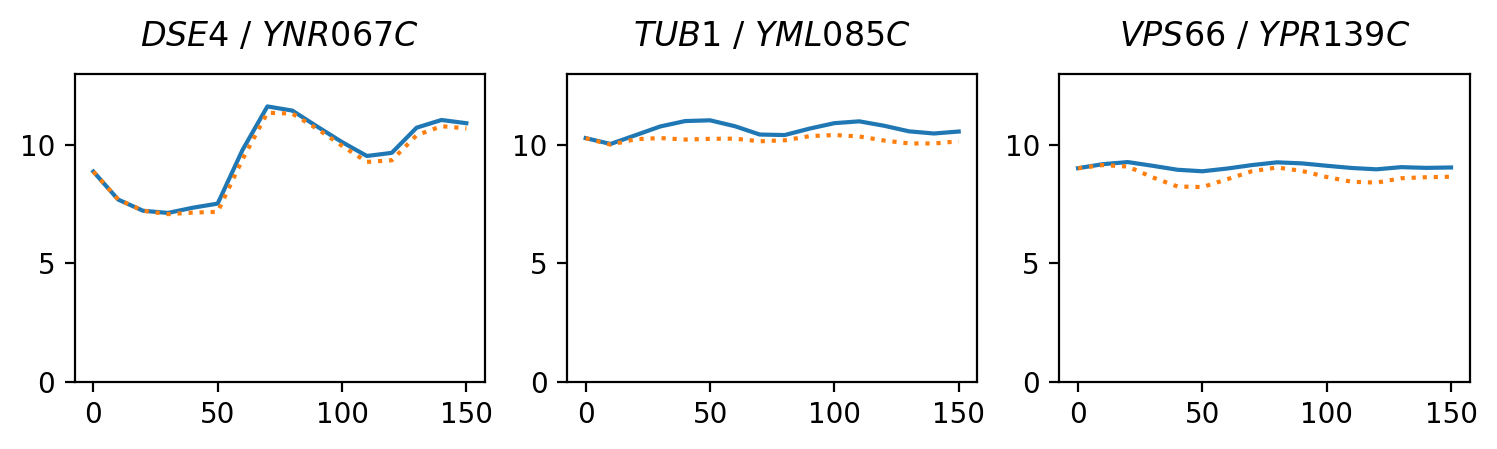

In [12]:

fig = plt.figure(figsize=(9, 2))
# A gene that stabilizes following copy number correction
plt.subplot(1, 3, 1)
corrector.plot_corrected_gene('YNR067C', fig=fig)
plt.ylim(0, 13)

plt.subplot(1, 3, 2)
# A gene that stabilizes following copy number correction
corrector.plot_corrected_gene('YML085C', fig=fig)
plt.ylim(0, 13)

plt.subplot(1, 3, 3)
# A gene that cycles following copy number correction
corrector.plot_corrected_gene('YPR139C', fig=fig)
plt.ylim(0, 13)
